In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import os

dataframes = {}

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        df_name = filename.split('.csv')[0]

        print(df_name)
        print(os.path.join(dirname, filename))

        dataframes[df_name] = pd.read_csv(
            os.path.join(dirname, filename)
        )

rentals
/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/rentals.csv
off_plan
/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/off_plan.csv
metro_stations
/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/metro_stations.csv
secondary_sales
/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/secondary_sales.csv
area_prices_monthly
/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/area_prices_monthly.csv


In [106]:
dataframes.keys()

dict_keys(['rentals', 'off_plan', 'metro_stations', 'secondary_sales', 'area_prices_monthly'])

In [107]:
df = dataframes['secondary_sales']

In [108]:
df.head()

,id,date_listed,community,zone,is_freehold,lat,lon,property_category,property_type,bedrooms,...,chiller_included,metro_station,metro_line,metro_distance_min,metro_distance_type,to_burj_khalifa_km,price_usd,price_per_sqft_usd,price_per_m2_usd,mortgage_rate_at_listing
0,S000001,2024-11-23,DIFC,DIFC,True,25.21053,55.29453,apartment,4BR_penthouse,4,...,True,Financial Centre,Red,6,walk,2.51,4806100,1314,14141,6.15
1,S000002,2023-07-05,DIFC,DIFC,True,25.21330,55.28617,apartment,3BR,3,...,True,Emirates Towers,Red,13,walk,2.15,2287400,1283,13813,6.90
2,S000003,2022-01-22,Karama,Bur Dubai,False,25.24835,55.29501,apartment,1BR,1,...,False,BurJuman (G),Green,14,walk,6.05,167100,203,2184,1.90
3,S000004,2021-10-28,The Valley,Dubai-Al Ain Road,True,24.95989,55.48870,villa,5BR_villa,5,...,False,Discovery Gardens,Red,151,drive,34.09,832000,154,1658,1.90
4,S000005,2025-05-30,Sobha Hartland,MBR City,True,25.17393,55.28697,apartment,3BR,3,...,True,Financial Centre,Red,23,drive,2.88,1323400,660,7104,6.15


In [109]:
df.shape

(50000, 29)

In [110]:
df.isnull().sum()

id                              0
date_listed                     0
community                       0
zone                            0
is_freehold                     0
lat                             0
lon                             0
property_category               0
property_type                   0
bedrooms                        0
area_sqft                       0
area_m2                         0
floor                       17820
total_floors                17820
year_built                      0
view                            0
furnishing                      0
condition                       0
parking_spaces                  0
chiller_included                0
metro_station                   0
metro_line                      0
metro_distance_min              0
metro_distance_type             0
to_burj_khalifa_km              0
price_usd                       0
price_per_sqft_usd              0
price_per_m2_usd                0
mortgage_rate_at_listing        0
dtype: int64

In [111]:
df.columns

Index(['id', 'date_listed', 'community', 'zone', 'is_freehold', 'lat', 'lon',
       'property_category', 'property_type', 'bedrooms', 'area_sqft',
       'area_m2', 'floor', 'total_floors', 'year_built', 'view', 'furnishing',
       'condition', 'parking_spaces', 'chiller_included', 'metro_station',
       'metro_line', 'metro_distance_min', 'metro_distance_type',
       'to_burj_khalifa_km', 'price_usd', 'price_per_sqft_usd',
       'price_per_m2_usd', 'mortgage_rate_at_listing'],
      dtype='object')

| Column | Example Value | Meaning |
|----------|----------|----------|
| `id` | `S044803` | Unique identifier for the property listing. |
| `date_listed` | `2020-12-18` | Date when the property was listed for sale. |
| `community` | `International City` | Specific neighborhood or community where the property is located. |
| `zone` | `International City` | Broader geographic area or district containing the property. |
| `is_freehold` | `True` | Indicates whether buyers can fully own the property. |
| `lat` | `25.15805` | Latitude coordinate of the property location. |
| `lon` | `55.42121` | Longitude coordinate of the property location. |
| `property_category` | `apartment` | General category of the property. |
| `property_type` | `3BR` | Specific property type or bedroom configuration. |
| `bedrooms` | `3` | Number of bedrooms in the property. |
| `area_sqft` | `2333` | Property size measured in square feet. |
| `area_m2` | `216.7` | Property size measured in square meters. |
| `floor` | `16` | Floor on which the property is located. |
| `total_floors` | `30` | Total number of floors in the building. |
| `year_built` | `2018` | Year the building was completed. |
| `view` | `community` | Main view available from the property. |
| `furnishing` | `unfurnished` | Furnishing status of the property. |
| `condition` | `vacant_on_transfer` | Current occupancy or transfer condition of the property. |
| `parking_spaces` | `1` | Number of dedicated parking spaces. |
| `chiller_included` | `True` | Indicates whether cooling/chiller costs are included. |
| `metro_station` | `Al Nahda` | Nearest metro station. |
| `metro_line` | `Red` | Metro line serving the nearest station. |
| `metro_distance_min` | `64` | Estimated travel time to the nearest metro station in minutes. |
| `metro_distance_type` | `drive` | Transportation mode used for the metro distance estimate. |
| `to_burj_khalifa_km` | `15.4` | Distance from the property to Burj Khalifa in kilometers. |
| `price_usd` | `166700` | Total listing price of the property in USD. |
| `price_per_sqft_usd` | `71` | Property price per square foot in USD. |
| `price_per_m2_usd` | `769` | Property price per square meter in USD. |
| `mortgage_rate_at_listing` | `1.9` | Average mortgage interest rate (%) when the property was listed. |

In [112]:
df.head()

,id,date_listed,community,zone,is_freehold,lat,lon,property_category,property_type,bedrooms,...,chiller_included,metro_station,metro_line,metro_distance_min,metro_distance_type,to_burj_khalifa_km,price_usd,price_per_sqft_usd,price_per_m2_usd,mortgage_rate_at_listing
0,S000001,2024-11-23,DIFC,DIFC,True,25.21053,55.29453,apartment,4BR_penthouse,4,...,True,Financial Centre,Red,6,walk,2.51,4806100,1314,14141,6.15
1,S000002,2023-07-05,DIFC,DIFC,True,25.21330,55.28617,apartment,3BR,3,...,True,Emirates Towers,Red,13,walk,2.15,2287400,1283,13813,6.90
2,S000003,2022-01-22,Karama,Bur Dubai,False,25.24835,55.29501,apartment,1BR,1,...,False,BurJuman (G),Green,14,walk,6.05,167100,203,2184,1.90
3,S000004,2021-10-28,The Valley,Dubai-Al Ain Road,True,24.95989,55.48870,villa,5BR_villa,5,...,False,Discovery Gardens,Red,151,drive,34.09,832000,154,1658,1.90
4,S000005,2025-05-30,Sobha Hartland,MBR City,True,25.17393,55.28697,apartment,3BR,3,...,True,Financial Centre,Red,23,drive,2.88,1323400,660,7104,6.15


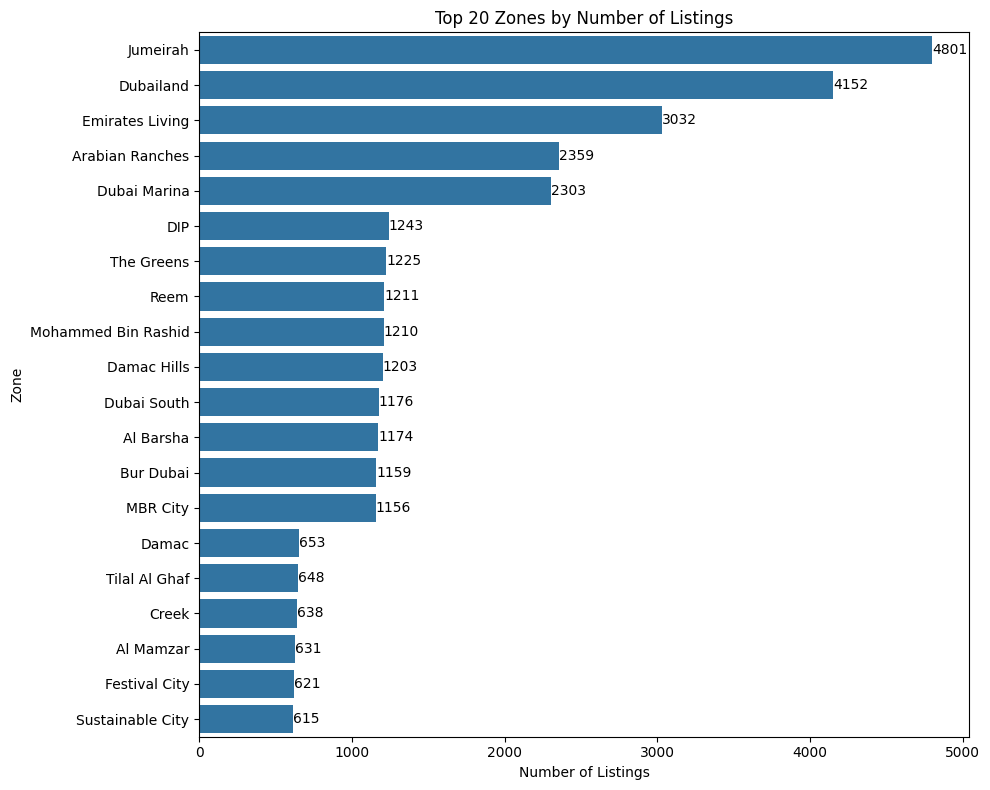

In [113]:
zone_counts = df['zone'].value_counts().head(20)

plt.figure(figsize=(10, 8))

ax = sns.barplot(
    x=zone_counts.values,
    y=zone_counts.index
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.title('Top 20 Zones by Number of Listings')
plt.xlabel('Number of Listings')
plt.ylabel('Zone')

plt.tight_layout()
plt.show()

### Do apartments or villas command higher average prices per square foot?

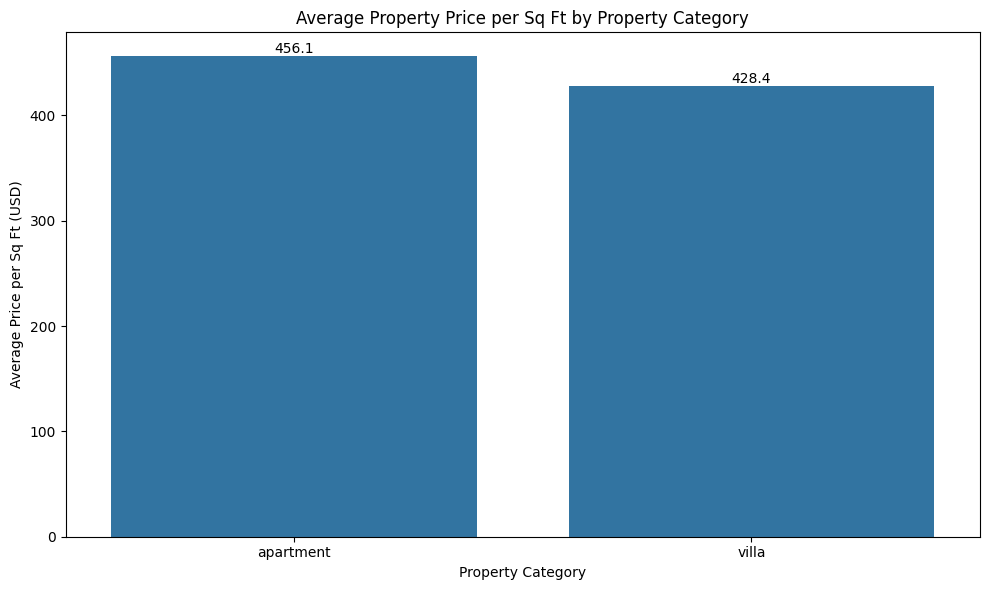

In [114]:
avg_price = (
    df.groupby('property_category')['price_per_sqft_usd']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=avg_price.index,
    y=avg_price.values
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title('Average Property Price per Sq Ft by Property Category')
plt.xlabel('Property Category')
plt.ylabel('Average Price per Sq Ft (USD)')

plt.tight_layout()
plt.show()

#### Insight:
Apartments have a higher average price per square foot (456 USD) compared to villas (428 USD). Although villas are generally larger and often have higher total transaction values, apartments appear to generate a stronger premium on a per-square-foot basis.

This may indicate stronger demand for apartments in prime urban locations, where buyers are willing to pay more for accessibility, amenities, and proximity to commercial centers.

### Which property types command the highest price per square foot in the market?

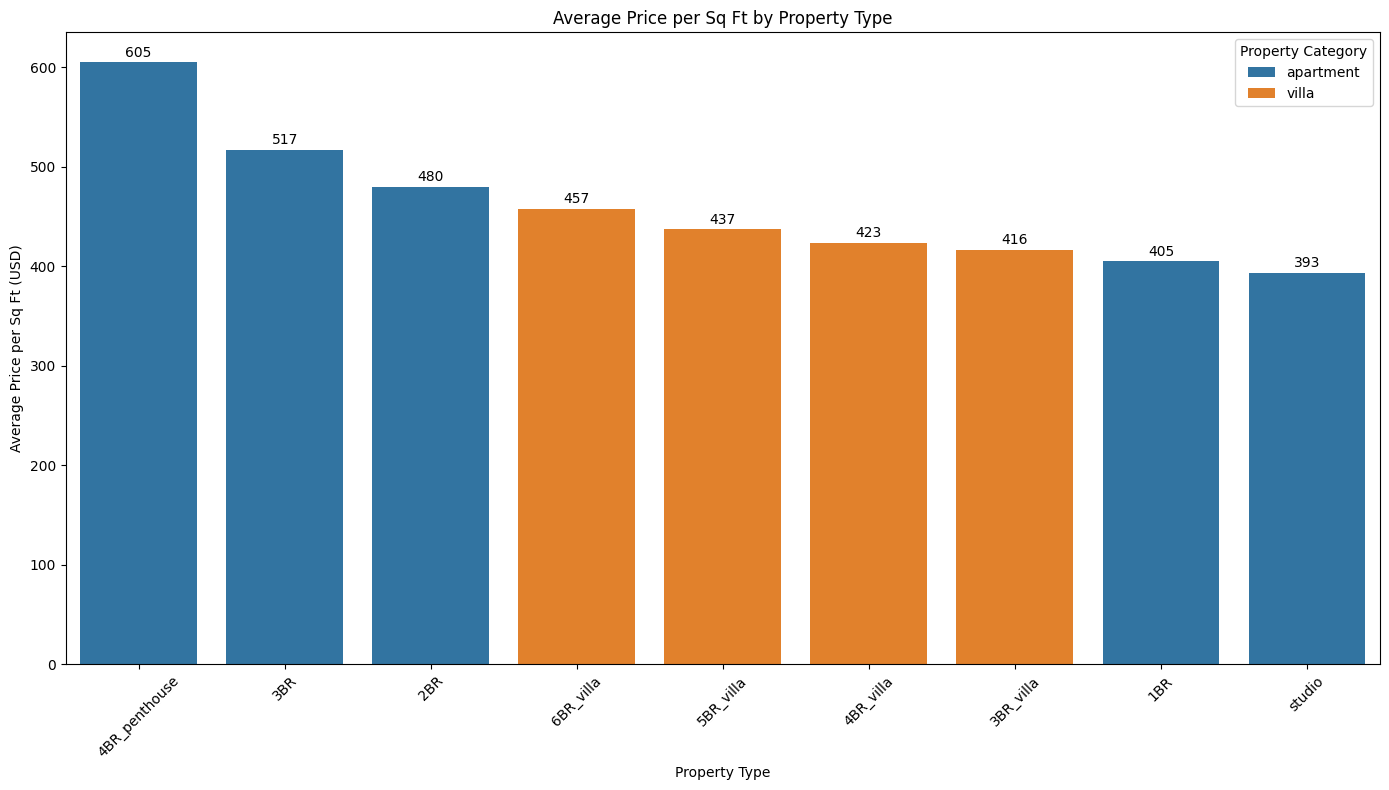

In [115]:
avg_prices = (
    df.groupby(['property_type', 'property_category'])['price_per_sqft_usd']
    .mean()
    .reset_index()
    .sort_values('price_per_sqft_usd', ascending=False)
)

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=avg_prices,
    x='property_type',
    y='price_per_sqft_usd',
    hue='property_category'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=2)

plt.title('Average Price per Sq Ft by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Average Price per Sq Ft (USD)')
plt.xticks(rotation=45)
plt.legend(title='Property Category')

plt.tight_layout()
plt.show()

#### Insight:
Significant variation exists across property types. The 4-bedroom penthouse segment commands the highest average price per square foot, indicating a strong luxury premium. Among standard apartment types, larger units such as 3-bedroom and 2-bedroom apartments also achieve relatively high prices per square foot.

Villa prices per square foot are comparatively more stable across bedroom configurations, ranging from approximately 416 to 457 USD per square foot. This suggests that location and land value may play a larger role in villa pricing than the number of bedrooms alone.

Overall, luxury apartments and penthouses appear to attract the highest per-unit valuations, highlighting strong demand for premium residential offerings.

### How are property prices distributed geographically across Dubai, and where are the premium real-estate clusters located?

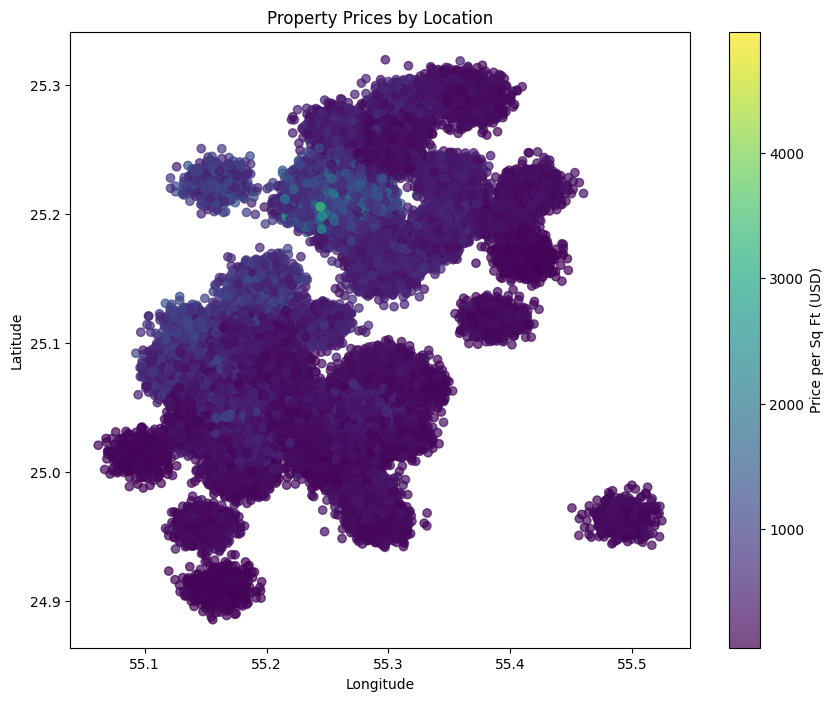

In [116]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    df['lon'],
    df['lat'],
    c=df['price_per_sqft_usd'],
    alpha=0.7
)

plt.colorbar(scatter, label='Price per Sq Ft (USD)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Property Prices by Location')

plt.show()